<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/python_course_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 0 — Python for Machine Learning

**Read this before the first class.**

This notebook is the shared starting point for the course. It is not a Python course
in itself: it is the *subset* of Python, NumPy and pandas that the labs actually use,
so that in class we can talk about machine learning instead of syntax.

### How to work through it

1. Run every cell (`Shift + Enter`). Do not just read them.
2. Change things. Break them. The fastest way to learn what a line does is to modify
   it and see what happens.
3. Do the exercises. Each one is followed by a solution cell — try it yourself first.

### Contents

| Part | Topic | Why it matters for the labs |
|------|-------|------------------------------|
| 1 | Python essentials | Every notebook |
| 2 | Object-oriented programming | Models are classes: `model.fit(X, y)`, PyTorch `nn.Module` |
| 3 | NumPy | Vectors, matrices, gradients — the from-scratch labs |
| 4 | pandas | Loading and inspecting datasets |
| 5 | Matplotlib | Every plot you will produce |
| 6 | Putting it together | A miniature end-to-end ML workflow |

### Time

About 60–90 minutes if you do the exercises.

In [1]:
# Everything below runs with these four libraries. If a cell fails with
# ModuleNotFoundError, uncomment the line that follows.
# !pip install numpy pandas matplotlib scikit-learn

import sys
print("Python", sys.version.split()[0])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("numpy", np.__version__)
print("pandas", pd.__version__)

Python 3.13.15
numpy 2.1.3
pandas 2.2.3


---
# Part 1 — Python essentials

## 1.1 Variables and types

Python is **dynamically typed**: you do not declare types, a variable simply refers to
an object. But it is **strongly typed** — it will not silently convert a string into a
number for you.

In [2]:
n_samples = 150          # int
learning_rate = 0.01     # float
model_name = "logistic"  # str
is_fitted = False        # bool
nothing = None           # NoneType — Python's "no value"

for value in (n_samples, learning_rate, model_name, is_fitted, nothing):
    print(f"{str(value):<10} -> {type(value).__name__}")

150        -> int
0.01       -> float
logistic   -> str
False      -> bool
None       -> NoneType


### f-strings

The `f"..."` prefix lets you embed expressions directly in a string. You will use this
constantly to print training metrics.

In [3]:
epoch, loss, acc = 7, 0.03421, 0.9812

print(f"epoch {epoch}: loss = {loss}, accuracy = {acc}")          # raw
print(f"epoch {epoch:3d}: loss = {loss:.4f}, accuracy = {acc:.2%}")  # formatted

# :3d  -> integer, width 3
# :.4f -> float, 4 decimals
# :.2% -> percentage, 2 decimals

epoch 7: loss = 0.03421, accuracy = 0.9812
epoch   7: loss = 0.0342, accuracy = 98.12%


## 1.2 The four containers

| Type | Written | Ordered | Mutable | Typical use |
|------|---------|---------|---------|-------------|
| `list` | `[1, 2, 3]` | yes | yes | a sequence you will modify (e.g. loss history) |
| `tuple` | `(1, 2, 3)` | yes | **no** | a fixed record — array shapes are tuples |
| `dict` | `{"a": 1}` | yes (insertion) | yes | named values — hyperparameters, config |
| `set` | `{1, 2, 3}` | no | yes | unique values — the set of class labels |

In [4]:
# ---- list -------------------------------------------------------------
losses = [0.9, 0.6, 0.4]
losses.append(0.3)          # add at the end
print("losses      :", losses)
print("first, last :", losses[0], losses[-1])   # negative index counts from the end
print("slice [1:3] :", losses[1:3])             # start included, stop excluded
print("length      :", len(losses))

# ---- tuple ------------------------------------------------------------
shape = (150, 4)            # 150 rows, 4 features
n_rows, n_cols = shape      # "unpacking"
print("unpacked    :", n_rows, n_cols)

# ---- dict -------------------------------------------------------------
params = {"lr": 0.01, "epochs": 100, "penalty": "l2"}
print("params[lr]  :", params["lr"])
params["batch_size"] = 32                       # add a key
print("keys        :", list(params.keys()))
print("get missing :", params.get("momentum", 0.9))  # default if absent

# ---- set --------------------------------------------------------------
labels = [0, 1, 1, 0, 2, 1, 2]
print("unique      :", set(labels))

losses      : [0.9, 0.6, 0.4, 0.3]
first, last : 0.9 0.3
slice [1:3] : [0.6, 0.4]
length      : 4
unpacked    : 150 4
params[lr]  : 0.01
keys        : ['lr', 'epochs', 'penalty', 'batch_size']
get missing : 0.9
unique      : {0, 1, 2}


> **Careful:** slicing uses `[start:stop]` with `stop` **excluded**. `losses[1:3]`
> gives elements 1 and 2, not 1, 2 and 3. This convention is everywhere in Python
> and NumPy.

## 1.3 Control flow

Python uses **indentation** (4 spaces) instead of braces to delimit blocks.

In [5]:
accuracy = 0.87

if accuracy > 0.95:
    verdict = "excellent"
elif accuracy > 0.80:
    verdict = "acceptable"
else:
    verdict = "needs work"

print(verdict)

# Loop over the elements themselves, not over indices:
for loss in [0.9, 0.6, 0.4]:
    print(f"  loss={loss}")

# Need the index too? enumerate.
for i, loss in enumerate([0.9, 0.6, 0.4]):
    print(f"  epoch {i}: {loss}")

# Two sequences in parallel? zip.
y_true = [0, 1, 1, 0]
y_pred = [0, 1, 0, 0]
for true, pred in zip(y_true, y_pred):
    mark = "ok" if true == pred else "WRONG"
    print(f"  true={true} pred={pred} {mark}")

acceptable
  loss=0.9
  loss=0.6
  loss=0.4
  epoch 0: 0.9
  epoch 1: 0.6
  epoch 2: 0.4
  true=0 pred=0 ok
  true=1 pred=1 ok
  true=1 pred=0 WRONG
  true=0 pred=0 ok


## 1.4 Functions

Define with `def`. Arguments can have **default values**, which makes them optional.

In [6]:
def accuracy_score(y_true, y_pred, as_percentage=False):
    """Fraction of predictions that match the ground truth.

    Parameters
    ----------
    y_true : list of int      Ground-truth labels.
    y_pred : list of int      Predicted labels.
    as_percentage : bool      If True, return 0-100 instead of 0-1.

    Returns
    -------
    float
    """
    n_correct = sum(t == p for t, p in zip(y_true, y_pred))
    score = n_correct / len(y_true)
    return score * 100 if as_percentage else score


y_true = [0, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1]

print(accuracy_score(y_true, y_pred))
print(accuracy_score(y_true, y_pred, as_percentage=True))
print(accuracy_score.__doc__.splitlines()[0])   # the docstring is accessible at runtime

0.8
80.0
Fraction of predictions that match the ground truth.


The text between triple quotes is a **docstring**. Write them: in Jupyter,
`help(accuracy_score)` or `accuracy_score?` will show it, and that is how you will
read scikit-learn's own documentation.

In [7]:
# Try it — this prints the full documentation of a NumPy function.
help(np.mean)

Help on _ArrayFunctionDispatcher in module numpy:

mean(
    a,
    axis=None,
    dtype=None,
    out=None,
    keepdims=<no value>,
    *,
    where=<no value>
)
    Compute the arithmetic mean along the specified axis.

    Returns the average of the array elements.  The average is taken over
    the flattened array by default, otherwise over the specified axis.
    `float64` intermediate and return values are used for integer inputs.

    Parameters
    ----------
    a : array_like
        Array containing numbers whose mean is desired. If `a` is not an
        array, a conversion is attempted.
    axis : None or int or tuple of ints, optional
        Axis or axes along which the means are computed. The default is to
        compute the mean of the flattened array.

        .. versionadded:: 1.7.0

        If this is a tuple of ints, a mean is performed over multiple axes,
        instead of a single axis or all the axes as before.
    dtype : data-type, optional
        Type to u

## 1.5 Comprehensions

A compact way to build a list from another sequence. Read it as
*"[ expression | for each item | if condition ]"*.

In [8]:
values = [1, 2, 3, 4, 5, 6]

# The verbose way:
squares = []
for v in values:
    squares.append(v ** 2)

# The Pythonic way:
squares = [v ** 2 for v in values]
evens   = [v for v in values if v % 2 == 0]
labels  = ["high" if v > 3 else "low" for v in values]

print(squares)
print(evens)
print(labels)

# Dict comprehension:
squared_map = {v: v ** 2 for v in values}
print(squared_map)

[1, 4, 9, 16, 25, 36]
[2, 4, 6]
['low', 'low', 'low', 'high', 'high', 'high']
{1: 1, 2: 4, 3: 9, 4: 16, 5: 25, 6: 36}


### Exercise 1

Write a function `standardise(values)` that takes a list of numbers and returns a new
list where each value has had the mean subtracted and is divided by the standard
deviation:

$$z_i = \frac{x_i - \mu}{\sigma}$$

Use only built-in Python (no NumPy yet). Check that the result has mean ≈ 0.

*Hint:* $\mu = \frac{1}{n}\sum x_i$ and $\sigma = \sqrt{\frac{1}{n}\sum (x_i-\mu)^2}$.

In [9]:
# Your turn:
def standardise(values):
    ...


# standardise([10, 12, 14, 16, 18])

<details>
<summary><b>Solution</b></summary>

Run the cell below.
</details>

In [10]:
def standardise(values):
    n = len(values)
    mu = sum(values) / n
    sigma = (sum((v - mu) ** 2 for v in values) / n) ** 0.5
    return [(v - mu) / sigma for v in values]


z = standardise([10, 12, 14, 16, 18])
print([round(v, 3) for v in z])
print("mean:", round(sum(z) / len(z), 10))

[-1.414, -0.707, 0.0, 0.707, 1.414]
mean: 0.0


---
# Part 2 — Object-oriented programming

## 2.1 Why you need this

Every model you will use in this course is an **object**:

```python
model = LogisticRegression(C=1.0)   # create an object, store its hyperparameters
model.fit(X_train, y_train)         # call a method that changes its internal state
y_pred = model.predict(X_test)      # call a method that uses that state
print(model.coef_)                  # read an attribute learnt during fit
```

That pattern — `__init__` / `fit` / `predict` — *is* the scikit-learn API, and PyTorch
models follow the same idea with `nn.Module`. So understanding classes is not optional
theory here; it is how you will read every lab.

## 2.2 A class, step by step

- A **class** is a blueprint. An **instance** is one concrete object built from it.
- `__init__` is the *constructor*: it runs when you create the instance and is where
  you store configuration.
- `self` is the instance itself. Every method receives it as its first argument, and
  you use it to read and write attributes that survive between calls.

In [11]:
class Dataset:
    """A tiny container for features and labels."""

    def __init__(self, X, y, name="unnamed"):
        # Attributes: data that belongs to THIS instance.
        self.X = X
        self.y = y
        self.name = name

    def n_samples(self):
        return len(self.y)

    def class_counts(self):
        counts = {}
        for label in self.y:
            counts[label] = counts.get(label, 0) + 1
        return counts


data = Dataset(X=[[1, 2], [3, 4], [5, 6], [7, 8]], y=[0, 1, 1, 1], name="toy")

print(data.name)             # attribute access — no parentheses
print(data.n_samples())      # method call     — with parentheses
print(data.class_counts())

toy
4
{0: 1, 1: 3}


## 2.3 Dunder methods

Methods named `__like_this__` ("double underscore" → *dunder*) hook into Python's
built-in syntax. Two you should recognise:

- `__repr__` — what Jupyter shows when you evaluate the object.
- `__len__` — what `len(obj)` returns.

PyTorch's `forward` is called through `__call__`, which is why you write `model(x)`
rather than `model.forward(x)`.

In [12]:
class Dataset:
    def __init__(self, X, y, name="unnamed"):
        self.X, self.y, self.name = X, y, name

    def __len__(self):
        return len(self.y)

    def __repr__(self):
        return f"Dataset(name={self.name!r}, n={len(self)}, n_features={len(self.X[0])})"


data = Dataset([[1, 2], [3, 4], [5, 6], [7, 8]], [0, 1, 1, 1], name="toy")

print(len(data))   # calls __len__
data               # calls __repr__

4


Dataset(name='toy', n=4, n_features=2)

## 2.4 Inheritance

A subclass **inherits** everything from its parent and can add to it or override it.
This is exactly how scikit-learn organises its estimators, and how you will define
networks in PyTorch (`class Net(nn.Module)`).

Below is a minimal version of the scikit-learn contract, so that the real thing looks
familiar when you meet it in Lab 1.

In [13]:
class BaseEstimator:
    """Minimal stand-in for the scikit-learn estimator interface."""

    def fit(self, X, y):
        raise NotImplementedError("Every subclass must implement fit().")

    def predict(self, X):
        raise NotImplementedError("Every subclass must implement predict().")

    def score(self, X, y):
        """Inherited by every subclass for free."""
        preds = self.predict(X)
        errors = [(p - t) ** 2 for p, t in zip(preds, y)]
        return sum(errors) / len(errors)          # mean squared error


class MeanRegressor(BaseEstimator):
    """The dumbest possible regressor: always predicts the training mean.

    Useful as a *baseline* — any real model must beat it.
    """

    def fit(self, X, y):
        self.mean_ = sum(y) / len(y)   # trailing underscore = learnt during fit
        return self                    # sklearn convention: fit returns self

    def predict(self, X):
        if not hasattr(self, "mean_"):
            raise RuntimeError("Call fit() before predict().")
        return [self.mean_ for _ in X]


X = [[1], [2], [3], [4], [5]]
y = [2.0, 4.1, 5.9, 8.2, 9.8]

model = MeanRegressor().fit(X, y)      # chaining works because fit returns self
print("learnt mean :", model.mean_)
print("predictions :", model.predict([[10], [20]]))
print("MSE         :", round(model.score(X, y), 3))   # inherited from BaseEstimator

learnt mean : 6.0
predictions : [6.0, 6.0]
MSE         : 7.78


Note the two conventions you will see everywhere in scikit-learn:

- `self.mean_` with a **trailing underscore**: an attribute learnt from data during
  `fit`. Hyperparameters set in `__init__` have no underscore.
- `fit` **returns `self`**, so `Model().fit(X, y).predict(X)` works in one line.

### Exercise 2

Write a `LastValueRegressor(BaseEstimator)` that predicts the **last** training target
instead of the mean. You only need to implement `fit` and `predict` — `score` comes
for free from the parent class.

In [14]:
# Your turn:
class LastValueRegressor(BaseEstimator):
    ...


# m = LastValueRegressor().fit(X, y)
# print(m.predict([[10]]), m.score(X, y))

<details>
<summary><b>Solution</b></summary>

Run the cell below.
</details>

In [15]:
class LastValueRegressor(BaseEstimator):
    def fit(self, X, y):
        self.value_ = y[-1]
        return self

    def predict(self, X):
        return [self.value_ for _ in X]


m = LastValueRegressor().fit(X, y)
print("prediction:", m.predict([[10]]))
print("MSE       :", round(m.score(X, y), 3), "(worse than the mean baseline — as expected)")

prediction: [9.8]
MSE       : 22.22 (worse than the mean baseline — as expected)


---
# Part 3 — NumPy

NumPy is the foundation of the entire scientific Python stack. A NumPy array is a
**contiguous block of memory of a single type**, which is why it is orders of magnitude
faster than a Python list — and why pandas, scikit-learn and PyTorch are all built on
it.

For this course the mental model is: **an array is a vector, a matrix, or a stack of
matrices**, and you manipulate it as a whole rather than element by element.

## 3.1 Creating arrays

The two attributes you will check constantly are `.shape` and `.dtype`. When a lab
throws an error, it is nearly always a shape mismatch — print the shape first.

In [16]:
a = np.array([1, 2, 3, 4])                 # from a list -> 1-D
M = np.array([[1, 2, 3], [4, 5, 6]])       # from nested lists -> 2-D

print("a      :", a,      "shape", a.shape, "dtype", a.dtype)
print("M      :\n", M, "\nshape", M.shape, "ndim", M.ndim)

print("\nzeros  :", np.zeros(3))
print("ones   :\n", np.ones((2, 3)))
print("arange :", np.arange(0, 10, 2))        # start, stop (excluded), step
print("linspace:", np.linspace(0, 1, 5))      # 5 points from 0 to 1, both included
print("eye    :\n", np.eye(3))                # identity matrix

a      : [1 2 3 4] shape (4,) dtype int64
M      :
 [[1 2 3]
 [4 5 6]] 
shape (2, 3) ndim 2

zeros  : [0. 0. 0.]
ones   :
 [[1. 1. 1.]
 [1. 1. 1.]]
arange : [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
eye    :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### Shape conventions in machine learning

Almost universally:

- `X` has shape **`(n_samples, n_features)`** — one row per observation.
- `y` has shape **`(n_samples,)`** — a 1-D vector of targets.

A very common bug is having `y` with shape `(n, 1)` instead of `(n,)`. Use
`.reshape(-1)` or `.ravel()` to flatten it; `-1` means *"work this dimension out for
me"*.

In [17]:
X = np.array([[5.1, 3.5], [4.9, 3.0], [4.7, 3.2], [4.6, 3.1]])
y = np.array([0, 0, 1, 1])

print("X.shape:", X.shape, "-> 4 samples, 2 features")
print("y.shape:", y.shape)

y_col = y.reshape(-1, 1)        # make it a column
print("as column:", y_col.shape)
print("back flat:", y_col.reshape(-1).shape)

X.shape: (4, 2) -> 4 samples, 2 features
y.shape: (4,)
as column: (4, 1)
back flat: (4,)


## 3.2 Indexing and slicing

For 2-D arrays the syntax is `array[rows, columns]`.

In [18]:
M = np.arange(12).reshape(3, 4)
print(M, "\n")

print("M[0, 0]   :", M[0, 0])        # single element
print("M[1]      :", M[1])           # whole row 1
print("M[:, 2]   :", M[:, 2])        # whole column 2  (':' = everything)
print("M[0:2, 1:3]:\n", M[0:2, 1:3]) # sub-block
print("M[-1]     :", M[-1])          # last row

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]] 

M[0, 0]   : 0
M[1]      : [4 5 6 7]
M[:, 2]   : [ 2  6 10]
M[0:2, 1:3]:
 [[1 2]
 [5 6]]
M[-1]     : [ 8  9 10 11]


### Boolean masking

This is the single most useful NumPy idiom for data work: build an array of `True`/`False`
and use it to select.

In [19]:
values = np.array([3.2, 7.8, 1.1, 9.4, 5.0])

mask = values > 5                       # elementwise comparison -> boolean array
print("mask        :", mask)
print("selected    :", values[mask])
print("how many    :", mask.sum())      # True counts as 1
print("in one line :", values[values > 5])

# Combine conditions with & (and) and | (or) — note the PARENTHESES, they are required.
print("between 2-6 :", values[(values > 2) & (values < 6)])

# Selecting rows of X by label — you will do this in every classification lab:
X = np.array([[5.1, 3.5], [4.9, 3.0], [4.7, 3.2], [4.6, 3.1]])
y = np.array([0, 0, 1, 1])
print("\nrows of class 1:\n", X[y == 1])

mask        : [False  True False  True False]
selected    : [7.8 9.4]
how many    : 2
in one line : [7.8 9.4]
between 2-6 : [3.2 5. ]

rows of class 1:
 [[4.7 3.2]
 [4.6 3.1]]


## 3.3 Vectorisation

**Never write a Python loop over array elements if a NumPy operation can do it.**
Operations apply elementwise to the whole array, in compiled C code.

In [20]:
a = np.array([1.0, 2.0, 3.0, 4.0])
b = np.array([10.0, 20.0, 30.0, 40.0])

print("a + b    :", a + b)
print("a * b    :", a * b)     # ELEMENTWISE product, not matrix multiplication
print("a ** 2   :", a ** 2)
print("a * 3    :", a * 3)     # scalar applied to every element
print("np.sqrt  :", np.sqrt(a))
print("np.exp   :", np.exp(a).round(2))

a + b    : [11. 22. 33. 44.]
a * b    : [ 10.  40.  90. 160.]
a ** 2   : [ 1.  4.  9. 16.]
a * 3    : [ 3.  6.  9. 12.]
np.sqrt  : [1.         1.41421356 1.73205081 2.        ]
np.exp   : [ 2.72  7.39 20.09 54.6 ]


In [21]:
# How much does vectorisation actually matter?
import time

big = np.random.rand(2_000_000)

t0 = time.perf_counter()
out_loop = [v ** 2 for v in big]          # pure Python
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
out_vec = big ** 2                        # NumPy
t_vec = time.perf_counter() - t0

print(f"Python loop : {t_loop*1000:8.1f} ms")
print(f"NumPy       : {t_vec*1000:8.1f} ms")
print(f"speed-up    : {t_loop/t_vec:8.0f}x")

Python loop :    806.1 ms
NumPy       :     25.0 ms
speed-up    :       32x


## 3.4 Reductions and the `axis` argument

`axis` is the dimension that gets **collapsed**:

- `axis=0` → collapse the rows → one result **per column** (per feature).
- `axis=1` → collapse the columns → one result **per row** (per sample).

Getting this backwards is a classic source of silent bugs, so say it out loud:
*"axis=0 gives me a value per feature"*.

In [22]:
X = np.array([[1.0, 10.0],
              [2.0, 20.0],
              [3.0, 30.0],
              [4.0, 40.0]])

print("X.shape          :", X.shape)
print("X.mean()         :", X.mean())              # over everything -> scalar
print("X.mean(axis=0)   :", X.mean(axis=0), "  <- per feature (2 values)")
print("X.mean(axis=1)   :", X.mean(axis=1), "<- per sample (4 values)")
print()
print("sum / min / max  :", X.sum(), X.min(), X.max())
print("std per feature  :", X.std(axis=0))
print("argmax per row   :", X.argmax(axis=1), " <- index of the largest value")

X.shape          : (4, 2)
X.mean()         : 13.75
X.mean(axis=0)   : [ 2.5 25. ]   <- per feature (2 values)
X.mean(axis=1)   : [ 5.5 11.  16.5 22. ] <- per sample (4 values)

sum / min / max  : 110.0 1.0 40.0
std per feature  : [ 1.11803399 11.18033989]
argmax per row   : [1 1 1 1]  <- index of the largest value


> `argmax(axis=1)` is how you turn a matrix of class probabilities into predicted
> labels. You will use that exact line in the multiclass deep learning labs.

## 3.5 Broadcasting

When shapes differ, NumPy **stretches** the smaller array along the missing dimensions
instead of copying data. This is what makes standardisation a one-liner.

In [23]:
X = np.array([[1.0, 10.0],
              [2.0, 20.0],
              [3.0, 30.0],
              [4.0, 40.0]])

mu = X.mean(axis=0)     # shape (2,)
sd = X.std(axis=0)      # shape (2,)

print("X  shape:", X.shape)
print("mu shape:", mu.shape)

# (4, 2) - (2,)  ->  mu is broadcast across all 4 rows
X_scaled = (X - mu) / sd

print("\nstandardised:\n", X_scaled.round(3))
print("\nnew mean per feature:", X_scaled.mean(axis=0).round(10))
print("new std  per feature:", X_scaled.std(axis=0).round(10))

X  shape: (4, 2)
mu shape: (2,)

standardised:
 [[-1.342 -1.342]
 [-0.447 -0.447]
 [ 0.447  0.447]
 [ 1.342  1.342]]

new mean per feature: [0. 0.]
new std  per feature: [1. 1.]


**The rule:** compare shapes from the right. Dimensions are compatible if they are
equal, or if one of them is 1. `(4, 2)` vs `(2,)` → the `(2,)` is treated as `(1, 2)`
→ compatible, stretched to `(4, 2)`.

In [24]:
# When it does NOT work, the error message tells you exactly which shapes clashed:
try:
    np.ones((4, 2)) + np.ones((3,))
except ValueError as e:
    print("ValueError:", e)

ValueError: operands could not be broadcast together with shapes (4,2) (3,) 


## 3.6 Linear algebra

`@` is matrix multiplication (`np.dot` does the same). This is the operation behind
every linear model and every neural network layer.

In [25]:
A = np.array([[1, 2], [3, 4]])
v = np.array([1, 1])

print("A @ v (matrix-vector):", A @ v)
print("A @ A (matrix-matrix):\n", A @ A)
print("A.T   (transpose)    :\n", A.T)
print("inverse              :\n", np.linalg.inv(A).round(3))

A @ v (matrix-vector): [3 7]
A @ A (matrix-matrix):
 [[ 7 10]
 [15 22]]
A.T   (transpose)    :
 [[1 3]
 [2 4]]
inverse              :
 [[-2.   1. ]
 [ 1.5 -0.5]]


### Preview of Lab 1

The closed-form solution of ordinary least squares is

$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Notice how directly the mathematics maps onto the code.

In [26]:
rng = np.random.default_rng(seed=0)

n = 100
x = rng.uniform(0, 10, size=n)
y = 3.0 + 2.0 * x + rng.normal(0, 1.0, size=n)     # true intercept 3, true slope 2

# Design matrix: a column of ones (the intercept) next to the feature.
X = np.column_stack([np.ones(n), x])               # shape (100, 2)

theta = np.linalg.inv(X.T @ X) @ X.T @ y

print("X.shape:", X.shape)
print(f"estimated intercept = {theta[0]:.3f}   (true 3.0)")
print(f"estimated slope     = {theta[1]:.3f}   (true 2.0)")

X.shape: (100, 2)
estimated intercept = 2.993   (true 3.0)
estimated slope     = 1.987   (true 2.0)


## 3.7 Random numbers and reproducibility

Always **seed** your random generator. Without a seed, your results change on every
run and neither you nor anyone marking your work can reproduce them.

The modern API is `np.random.default_rng(seed)`; you will also see the older
`np.random.seed(42)` style in existing code.

In [27]:
rng = np.random.default_rng(seed=42)

print("uniform [0,1) :", rng.random(3).round(3))
print("normal(0,1)   :", rng.normal(0, 1, 3).round(3))
print("integers      :", rng.integers(0, 10, 5))
print("shuffled idx  :", rng.permutation(10))

# Same seed -> same numbers, every time, on every machine.
print("\nreproducible  :", np.random.default_rng(42).random(3).round(3))

uniform [0,1) : [0.774 0.439 0.859]
normal(0,1)   : [ 0.941 -1.951 -1.302]
integers      : [7 7 7 7 5]
shuffled idx  : [7 0 4 2 3 5 1 8 9 6]

reproducible  : [0.774 0.439 0.859]


### Exercise 3

Given the array below:

1. Compute the mean of each **column**.
2. Select the rows where the value in the **first column** is greater than 3.
3. Standardise the whole array (zero mean, unit variance, per column) in one line.
4. Compute the pairwise product `X @ X.T` and report its shape.

In [28]:
X = np.array([[1.0, 2.0],
              [3.0, 6.0],
              [5.0, 4.0],
              [7.0, 8.0]])

# Your turn:

<details>
<summary><b>Solution</b></summary>

Run the cell below.
</details>

In [29]:
X = np.array([[1.0, 2.0],
              [3.0, 6.0],
              [5.0, 4.0],
              [7.0, 8.0]])

# 1
print("column means :", X.mean(axis=0))

# 2
print("rows col0>3  :\n", X[X[:, 0] > 3])

# 3
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
print("standardised :\n", X_std.round(3))

# 4
G = X @ X.T
print("X @ X.T shape:", G.shape)

column means : [4. 5.]
rows col0>3  :
 [[5. 4.]
 [7. 8.]]
standardised :
 [[-1.342 -1.342]
 [-0.447  0.447]
 [ 0.447 -0.447]
 [ 1.342  1.342]]
X @ X.T shape: (4, 4)


---
# Part 4 — pandas

NumPy arrays are homogeneous and anonymous. Real datasets have **named columns of
different types**, some of them text, some with missing values. That is what pandas is
for.

- A **`Series`** is one column: a 1-D array with an index.
- A **`DataFrame`** is a table: a dict of `Series` sharing one index.

The workflow in the labs is always the same: *load with pandas → explore and clean with
pandas → hand a NumPy array to the model*.

In [30]:
s = pd.Series([5.1, 4.9, 4.7, 4.6], name="sepal_length")
print(s, "\n")
print("values are a NumPy array:", type(s.values).__name__, s.values)

0    5.1
1    4.9
2    4.7
3    4.6
Name: sepal_length, dtype: float64 

values are a NumPy array: ndarray [5.1 4.9 4.7 4.6]


In [31]:
# Building a DataFrame from a dict: keys become column names.
df = pd.DataFrame({
    "sepal_length": [5.1, 4.9, 4.7, 4.6, 6.5, 6.0, 6.7, 5.8],
    "sepal_width":  [3.5, 3.0, 3.2, 3.1, 3.0, 2.7, 3.1, 2.7],
    "petal_length": [1.4, 1.4, 1.3, 1.5, 5.2, 5.1, 4.7, 5.1],
    "species":      ["setosa", "setosa", "setosa", "setosa",
                     "virginica", "virginica", "versicolor", "virginica"],
})

df

,sepal_length,sepal_width,petal_length,species
0,5.1,3.5,1.4,setosa
1,4.9,3.0,1.4,setosa
2,4.7,3.2,1.3,setosa
3,4.6,3.1,1.5,setosa
4,6.5,3.0,5.2,virginica
5,6.0,2.7,5.1,virginica
6,6.7,3.1,4.7,versicolor
7,5.8,2.7,5.1,virginica


## 4.1 First look at any dataset

These four commands are the first thing you should run on data you have never seen.

In [32]:
print("shape:", df.shape, "\n")     # (rows, columns)
df.head(3)                          # first rows

shape: (8, 4) 



,sepal_length,sepal_width,petal_length,species
0,5.1,3.5,1.4,setosa
1,4.9,3.0,1.4,setosa
2,4.7,3.2,1.3,setosa


In [33]:
df.info()                           # column types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  8 non-null      float64
 1   sepal_width   8 non-null      float64
 2   petal_length  8 non-null      float64
 3   species       8 non-null      object 
dtypes: float64(3), object(1)
memory usage: 388.0+ bytes


In [34]:
df.describe()                       # summary statistics of the NUMERIC columns

,sepal_length,sepal_width,petal_length
count,8.000000,8.00000,8.000000
mean,5.537500,3.03750,3.212500
std,0.822778,0.26152,1.943809
min,4.600000,2.70000,1.300000
25%,4.850000,2.92500,1.400000
50%,5.450000,3.05000,3.100000
75%,6.125000,3.12500,5.100000
max,6.700000,3.50000,5.200000


In [35]:
print(df.columns.tolist())
print(df.dtypes.to_dict())
print(df["species"].value_counts())   # class balance — always check this

['sepal_length', 'sepal_width', 'petal_length', 'species']
{'sepal_length': dtype('float64'), 'sepal_width': dtype('float64'), 'petal_length': dtype('float64'), 'species': dtype('O')}
species
setosa        4
virginica     3
versicolor    1
Name: count, dtype: int64


## 4.2 Selecting

- `df["col"]` → one column, as a `Series`.
- `df[["a", "b"]]` → several columns, as a `DataFrame` (note the double brackets).
- `df.loc[rows, cols]` → selection **by label**.
- `df.iloc[rows, cols]` → selection **by integer position**.

In [36]:
print(type(df["sepal_length"]).__name__, "<- single brackets")
print(type(df[["sepal_length", "sepal_width"]]).__name__, "<- double brackets")
print()

print("loc  (label)   :\n", df.loc[0:2, ["sepal_length", "species"]], "\n")
print("iloc (position):\n", df.iloc[0:2, [0, 3]])

Series <- single brackets
DataFrame <- double brackets

loc  (label)   :
    sepal_length species
0           5.1  setosa
1           4.9  setosa
2           4.7  setosa 

iloc (position):
    sepal_length species
0           5.1  setosa
1           4.9  setosa


> Subtle but important: `df.loc[0:2]` includes row 2, whereas `df.iloc[0:2]` excludes
> position 2. `loc` is inclusive of the end label; `iloc` follows normal Python slicing.

## 4.3 Filtering

Same boolean-mask idea as NumPy.

In [37]:
print(df[df["petal_length"] > 5.0], "\n")

# Multiple conditions: & and |, each condition in parentheses.
subset = df[(df["species"] == "virginica") & (df["sepal_width"] < 3.0)]
print(subset, "\n")

print(df[df["species"].isin(["setosa", "versicolor"])].shape)

   sepal_length  sepal_width  petal_length    species
4           6.5          3.0           5.2  virginica
5           6.0          2.7           5.1  virginica
7           5.8          2.7           5.1  virginica 

   sepal_length  sepal_width  petal_length    species
5           6.0          2.7           5.1  virginica
7           5.8          2.7           5.1  virginica 

(5, 4)


## 4.4 Creating columns and applying functions

In [38]:
df = df.copy()

# Vectorised — the preferred way.
df["petal_ratio"] = df["petal_length"] / df["sepal_length"]

# Elementwise with a function, when there is no vectorised equivalent.
df["size_class"] = df["petal_length"].apply(lambda v: "large" if v > 4 else "small")

# Mapping categories to integers — models need numbers, not strings.
species_to_int = {"setosa": 0, "versicolor": 1, "virginica": 2}
df["target"] = df["species"].map(species_to_int)

df.head()

,sepal_length,sepal_width,petal_length,species,petal_ratio,size_class,target
0,5.1,3.5,1.4,setosa,0.274510,small,0
1,4.9,3.0,1.4,setosa,0.285714,small,0
2,4.7,3.2,1.3,setosa,0.276596,small,0
3,4.6,3.1,1.5,setosa,0.326087,small,0
4,6.5,3.0,5.2,virginica,0.800000,large,2


## 4.5 Grouping

`groupby` splits the table by the values of a column, applies an aggregation to each
group, and combines the results — the *split–apply–combine* pattern.

In [39]:
print(df.groupby("species")["petal_length"].mean(), "\n")

print(df.groupby("species").agg(
    n=("petal_length", "size"),
    mean_petal=("petal_length", "mean"),
    max_sepal=("sepal_length", "max"),
))

species
setosa        1.400000
versicolor    4.700000
virginica     5.133333
Name: petal_length, dtype: float64 

            n  mean_petal  max_sepal
species                             
setosa      4    1.400000        5.1
versicolor  1    4.700000        6.7
virginica   3    5.133333        6.5


## 4.6 Missing values

Real data has holes. pandas represents them as `NaN`, and you must decide explicitly
what to do with them — dropping rows and imputing are both legitimate, but they are
different modelling choices.

In [40]:
dirty = df[["sepal_length", "sepal_width", "petal_length"]].copy()
dirty.loc[1, "sepal_width"] = np.nan
dirty.loc[5, "petal_length"] = np.nan

print("missing per column:\n", dirty.isna().sum(), "\n")
print("rows with any NaN :", dirty.isna().any(axis=1).sum(), "\n")

print("dropna() ->", dirty.dropna().shape)
print("fillna(mean) ->\n", dirty.fillna(dirty.mean()).round(3))

missing per column:
 sepal_length    0
sepal_width     1
petal_length    1
dtype: int64 

rows with any NaN : 2 

dropna() -> (6, 3)
fillna(mean) ->
    sepal_length  sepal_width  petal_length
0           5.1        3.500         1.400
1           4.9        3.043         1.400
2           4.7        3.200         1.300
3           4.6        3.100         1.500
4           6.5        3.000         5.200
5           6.0        2.700         2.943
6           6.7        3.100         4.700
7           5.8        2.700         5.100


## 4.7 Handing data to a model

scikit-learn accepts DataFrames, but the labs often convert explicitly so that shapes
are unambiguous. `.values` (or `.to_numpy()`) gives you the underlying NumPy array.

In [41]:
feature_cols = ["sepal_length", "sepal_width", "petal_length"]

X = df[feature_cols].to_numpy()     # (n_samples, n_features)
y = df["target"].to_numpy()         # (n_samples,)

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print(X[:3])

X: (8, 3) float64
y: (8,) int64
[[5.1 3.5 1.4]
 [4.9 3.  1.4]
 [4.7 3.2 1.3]]


### Reading a real file

You will rarely type data by hand. In the labs, data comes from a CSV:

```python
df = pd.read_csv("data/data.csv")          # local file
df = pd.read_csv("https://.../data.csv")   # or straight from a URL
```

`read_csv` has useful arguments: `sep=";"`, `header=None`, `names=[...]`,
`na_values=["?", "N/A"]`, `usecols=[...]`.

### Exercise 4

Using `df`:

1. How many samples are there of each `species`?
2. What is the mean `sepal_width` of the `virginica` samples only?
3. Add a column `is_setosa` that is `1` for setosa and `0` otherwise.
4. Return a DataFrame with only the numeric columns, sorted by `petal_length`
   descending.

In [42]:
# Your turn:

<details>
<summary><b>Solution</b></summary>

Run the cell below.
</details>

In [43]:
# 1
print(df["species"].value_counts(), "\n")

# 2
print("mean sepal_width (virginica):",
      df.loc[df["species"] == "virginica", "sepal_width"].mean().round(3), "\n")

# 3
df["is_setosa"] = (df["species"] == "setosa").astype(int)
print(df[["species", "is_setosa"]].head(), "\n")

# 4
numeric = df.select_dtypes(include="number")
print(numeric.sort_values("petal_length", ascending=False).head())

species
setosa        4
virginica     3
versicolor    1
Name: count, dtype: int64 

mean sepal_width (virginica): 2.8 

     species  is_setosa
0     setosa          1
1     setosa          1
2     setosa          1
3     setosa          1
4  virginica          0 

   sepal_length  sepal_width  petal_length  petal_ratio  target  is_setosa
4           6.5          3.0           5.2     0.800000       2          0
5           6.0          2.7           5.1     0.850000       2          0
7           5.8          2.7           5.1     0.879310       2          0
6           6.7          3.1           4.7     0.701493       1          0
3           4.6          3.1           1.5     0.326087       0          1


---
# Part 5 — Matplotlib in five minutes

You need three things: a scatter plot, a line plot, and how to label them. Everything
else you can look up when you need it.

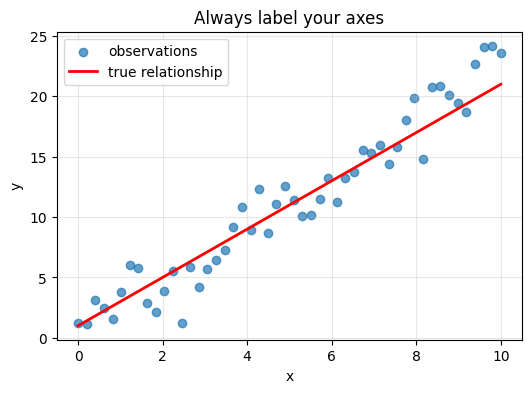

In [44]:
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + rng.normal(0, 2, size=50)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.7, label="observations")
plt.plot(x, 2 * x + 1, color="red", linewidth=2, label="true relationship")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Always label your axes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

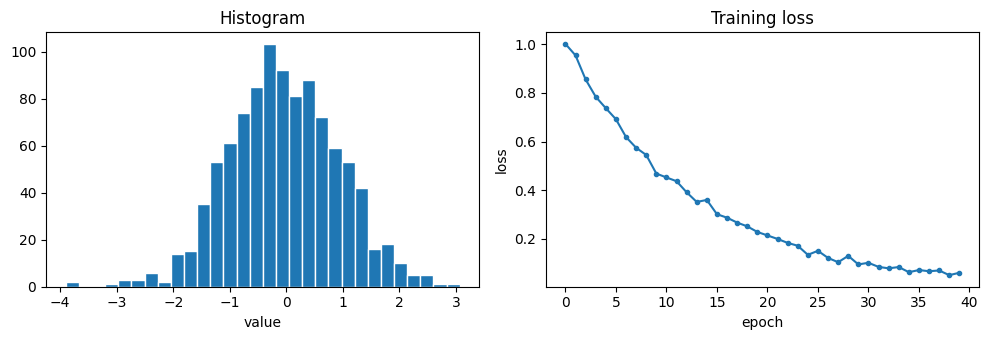

In [45]:
# Several panels at once: fig (the canvas) and axes (the individual plots).
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(rng.normal(0, 1, 1000), bins=30, edgecolor="white")
axes[0].set_title("Histogram")
axes[0].set_xlabel("value")

losses = np.exp(-np.linspace(0, 3, 40)) + rng.normal(0, 0.01, 40)
axes[1].plot(losses, marker="o", markersize=3)
axes[1].set_title("Training loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()

> With `plt.subplots` you call methods on the *axes* object, and the names change
> slightly: `plt.xlabel(...)` becomes `ax.set_xlabel(...)`, `plt.title(...)` becomes
> `ax.set_title(...)`.

---
# Part 6 — Putting it together

Here is a complete, miniature version of what every lab in Part 1 of the course does.
Read it as a checklist of the skills above being used together.

In [46]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load ------------------------------------------------------------------
data = load_diabetes(as_frame=True)
df = data.frame
print("shape:", df.shape)
print(df.head(3))

shape: (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  


In [47]:
# 2. Split into features and target, then into train and test ---------------
X = df.drop(columns="target").to_numpy()
y = df["target"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42       # random_state -> reproducible split
)
print("train:", X_train.shape, " test:", X_test.shape)

train: (353, 10)  test: (89, 10)


In [48]:
# 3. Preprocess -------------------------------------------------------------
# Fit the scaler on the TRAINING data only, then apply it to both.
# Fitting on the full dataset leaks test information into training.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("train feature means (≈0):", X_train_s.mean(axis=0).round(3)[:5])

train feature means (≈0): [ 0.  0. -0.  0. -0.]


In [49]:
# 4. Fit, predict, evaluate -------------------------------------------------
model = LinearRegression().fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print(f"RMSE : {mean_squared_error(y_test, y_pred) ** 0.5:.2f}")
print(f"R²   : {r2_score(y_test, y_pred):.3f}")

# Compare against the trivial baseline from Part 2 — a model is only good relative
# to something.
baseline_rmse = mean_squared_error(y_test, np.full_like(y_test, y_train.mean())) ** 0.5
print(f"baseline RMSE (predict the mean): {baseline_rmse:.2f}")

RMSE : 53.85
R²   : 0.453
baseline RMSE (predict the mean): 73.22


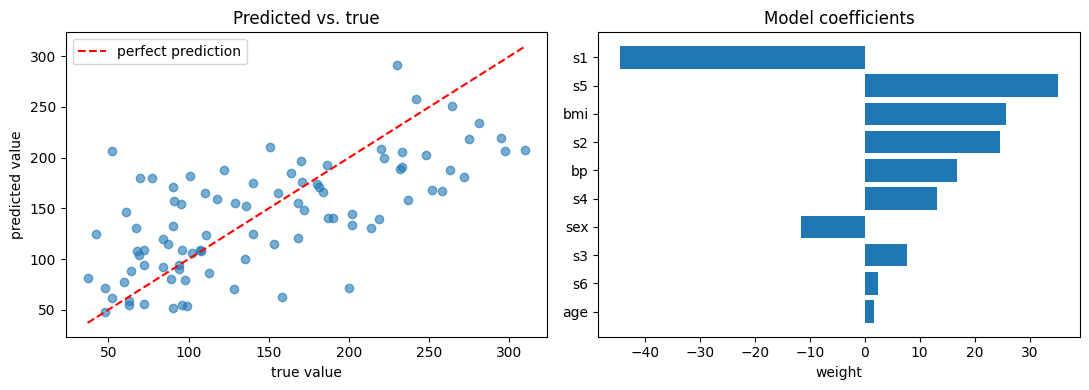

In [50]:
# 5. Look at the result -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_test, y_pred, alpha=0.6)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--", label="perfect prediction")
axes[0].set_xlabel("true value")
axes[0].set_ylabel("predicted value")
axes[0].set_title("Predicted vs. true")
axes[0].legend()

feature_names = df.drop(columns="target").columns
order = np.argsort(np.abs(model.coef_))
axes[1].barh(feature_names[order], model.coef_[order])
axes[1].set_title("Model coefficients")
axes[1].set_xlabel("weight")

plt.tight_layout()
plt.show()

---
# Before the first class

You are ready if you can answer these without looking them up:

- [ ] What is the difference between a `list` and a `dict`, and when do you use each?
- [ ] What does `self` refer to inside a method?
- [ ] What do `fit` and `predict` do, and why does `fit` return `self`?
- [ ] Given `X.shape == (150, 4)`, how many samples and how many features are there?
- [ ] What does `X.mean(axis=0)` return, and what shape does it have?
- [ ] Why is `(X - X.mean(axis=0)) / X.std(axis=0)` valid despite the shape mismatch?
- [ ] How do you select the rows of `X` whose label is 1?
- [ ] What is the difference between `df.loc` and `df.iloc`?
- [ ] Why must the scaler be fitted on the training set only?

If any of these is shaky, go back to that section — the labs assume all of them.

### If you want more

- [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [scikit-learn: getting started](https://scikit-learn.org/stable/getting_started.html)
- Python Data Science Handbook, J. VanderPlas — free online, chapters 2 and 3

### Useful in Jupyter and Colab

| Shortcut | Does |
|----------|------|
| `Shift + Enter` | Run cell, move to the next |
| `Ctrl + Enter` | Run cell, stay |
| `Esc` then `A` / `B` | Insert a cell above / below |
| `Esc` then `D D` | Delete the cell |
| `Esc` then `M` / `Y` | Convert to markdown / code |
| `Tab` | Autocomplete |
| `Shift + Tab` | Show the signature of the function under the cursor |
| `object?` | Show the docstring |

**Next:** Lab 1 — *Ordinary Least Squares Regression*.